In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip show tensorflow

Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tf_keras, ydf_tf


In [ ]:
root = '/content/drive/MyDrive/Ravaee/CondInfoGAN/5_28_2026'

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from tensorflow.keras.initializers import he_normal
import datetime
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import os
import shutil

In [ ]:
output_dir = "generated_images"

# Remove the directory and all its contents if it exists
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

# Create a fresh directory
os.makedirs(output_dir)

In [ ]:
from pathlib import Path
log_path = Path("training_log.txt")
log_path.write_text("", encoding="utf-8")


def log_message(message):
    with log_path.open("a", encoding="utf-8") as f:
        f.write(f"{message}\n")

In [ ]:
batch_size = 64
num_channels = 1
image_size = 128
latent_dim = 128

In [ ]:
data = np.load('/content/drive/MyDrive/Ravaee/CondInfoGAN/5_28_2026/data.npy')
types = open('/content/drive/MyDrive/Ravaee/CondInfoGAN/5_28_2026/types.txt').readlines()
sub_types = open('/content/drive/MyDrive/Ravaee/CondInfoGAN/5_28_2026/subtypes.txt').readlines()

# data = np.load('data.npy')
# types = open('types.txt').readlines()
# sub_types = open('subtypes.txt').readlines()

In [ ]:
p_low = np.percentile(data, 1)    # or 2nd percentile
p_high = np.percentile(data, 99)  # or 98th percentile

data_clipped = np.clip(data, p_low, p_high)
data = 2 * (data_clipped - p_low) / (p_high - p_low) - 1

In [ ]:
df = pd.DataFrame(columns=['id','type','subtype','type_code', 'subtype_code'])
df.id = np.arange(data.shape[0])
df.type = types
df.type = df.type.str.strip()
df.subtype = sub_types
df.subtype = df.subtype.str.strip()
df = df.drop(df[df.type=='NA'].index)
df = df.drop(df[df.subtype=='NA'].index)
df = df[df.subtype.isin(['Primary Tumor', 'Solid Tissue Normal', 'Metastatic', 'Recurrent Tumor'])]
df.type_code = LabelEncoder().fit_transform(df.type)
df.subtype_code = LabelEncoder().fit_transform(df.subtype)

In [ ]:
primary_df = df[df.subtype=='Primary Tumor']
primary_df = primary_df.sample(n=726)
df = df.drop(df[df.subtype=='Primary Tumor'].index)
df = pd.concat([df,primary_df],axis=0)

In [ ]:
x_train = data[df.id.values]
y_train = df.type_code.values
y_train = to_categorical(y_train)
c_cat_dim = len(df.subtype.unique())
num_classes = y_train.shape[1]
s_train = df.subtype_code.values
s_train = to_categorical(s_train, num_classes=c_cat_dim)

label_ratio = 0.05
n_total = len(s_train)
label_mask = np.zeros(n_total, dtype=np.float32)
sample_weights = np.zeros(n_total, dtype=np.float32)
subtype_codes = df.subtype_code.values
labeled_counts = {}
for st in range(c_cat_dim):
    st_indices = np.where(subtype_codes == st)[0]
    n_labeled = max(1, int(len(st_indices) * label_ratio))
    chosen = np.random.choice(st_indices, size=n_labeled, replace=False)
    label_mask[chosen] = 1.0
    labeled_counts[st] = n_labeled
total_labeled = int(label_mask.sum())
for st in range(c_cat_dim):
    st_labeled_idx = np.where((subtype_codes == st) & (label_mask == 1.0))[0]
    weight = total_labeled / (c_cat_dim * labeled_counts[st])
    sample_weights[st_labeled_idx] = weight
print(f"Semi-supervised: {total_labeled}/{n_total} labeled ({total_labeled/n_total*100:.1f}%)")
for st in range(c_cat_dim):
    w = sample_weights[np.where((subtype_codes == st) & (label_mask == 1.0))[0]]
    print(f"  Subtype {st}: {labeled_counts[st]} labeled, weight={w[0]:.2f}")

Semi-supervised: 93/1889 labeled (4.9%)
  Subtype 0: 19 labeled, weight=1.22
  Subtype 1: 36 labeled, weight=0.65
  Subtype 2: 2 labeled, weight=11.62
  Subtype 3: 36 labeled, weight=0.65


In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((tf.cast(x_train, tf.float32), y_train, s_train, label_mask, sample_weights))
dataset = dataset.shuffle(buffer_size=1024).batch(batch_size)

print(f"Shape of training images: {x_train.shape}")
print(f"Shape of training labels: {y_train.shape}")
print(f"Shape of subtype labels: {s_train.shape}")
print(f"Shape of label mask: {label_mask.shape}")
print(f"Shape of sample weights: {sample_weights.shape}")

Shape of training images: (1889, 128, 128, 1)
Shape of training labels: (1889, 32)
Shape of subtype labels: (1889, 4)
Shape of label mask: (1889,)
Shape of sample weights: (1889,)


In [ ]:
generator_in_channels = latent_dim + num_classes + c_cat_dim
print(generator_in_channels)

164


In [ ]:
def get_discriminator():
  label_layer = layers.Input(shape=(num_classes,))
  li = layers.Dense(image_size * image_size, use_bias=False)(label_layer)
  li = layers.Reshape((image_size, image_size, 1))(li)
  input_layer = layers.Input(shape=(image_size, image_size, num_channels))
  x = layers.Concatenate()([li, input_layer])
  x = layers.Conv2D(64, (3, 3), strides=(2, 2), padding="same")(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2D(128, (3, 3), strides=(2, 2), padding="same")(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2D(256, (3, 3), strides=(2, 2), padding="same")(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2D(256, (3, 3), strides=(2, 2), padding="same")(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2D(512, (3, 3), strides=(2, 2), padding="same")(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  shared_features = layers.GlobalMaxPooling2D()(x)
  disc_out = layers.Dense(1, name='disc_out')(shared_features)
  d_model = keras.models.Model([input_layer, label_layer], disc_out, name="discriminator")
  ####
  q_features = layers.Lambda(lambda x: tf.stop_gradient(x))(shared_features)
  ####
  x = layers.Dense(512, kernel_initializer='he_normal')(q_features)
  x = layers.LeakyReLU(0.2)(x)
  x = layers.Dropout(0.2)(x)
  x = layers.Dense(256, kernel_initializer='he_normal')(x)
  x = layers.LeakyReLU(0.2)(x)
  x = layers.Dropout(0.2)(x)
  x = layers.Dense(c_cat_dim, kernel_initializer='he_normal' )(x)
  q_out = layers.Activation('softmax')(x)
  q_model = keras.models.Model([input_layer, label_layer], q_out, name='q_network')


  return d_model , q_model

In [ ]:
def get_generator_model():
  noise = layers.Input(shape=(latent_dim,) , name='noise')
  labels = layers.Input(shape=(c_cat_dim,), name='c_cat')
  class_label = layers.Input(shape=(num_classes,), name='class_label')
  inputs =layers.concatenate([noise,labels,class_label], axis=1)
  x = layers.Dense(8 * 8 * (latent_dim+c_cat_dim+num_classes), name='gen_l1')(inputs)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Reshape((8, 8, latent_dim+c_cat_dim+num_classes))(x)
  x = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding="same",use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding="same",use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding="same",use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2DTranspose(128, (7, 7), strides=(2, 2), padding="same",use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2D(1, (7, 7), padding="same",use_bias=False)(x)
  # x = layers.BatchNormalization()(x)
  x = layers.Activation('tanh',name='gen_out')(x)
  g_model = keras.models.Model([noise,labels,class_label], x, name="generator")
  return g_model

In [ ]:
discriminator, q_network = get_discriminator()
discriminator.summary()
q_network.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16384)     │    524,288 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 128, 128,  │          0 │ dense[0][0]       │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ reshape[0][0],    │
│ (Concatenate)       │ 2)                │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      1,216 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     73,856 │ leaky_re_lu[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │    295,168 │ leaky_re_lu_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 16, 16,    │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 256) │    590,080 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 8, 8, 256) │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 4, 4, 512) │  1,180,160 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 4, 4, 512) │          0 │ conv2d_4[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 512)       │          0 │ leaky_re_lu_4[0]… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_out (Dense)    │ (None, 1)         │        513 │ global_max_pooli… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,665,281 (10.17 MB)

 Trainable params: 2,665,281 (10.17 MB)

...

Model: "q_network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16384)     │    524,288 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 128, 128,  │          0 │ dense[0][0]       │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ reshape[0][0],    │
│ (Concatenate)       │ 2)                │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      1,216 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     73,856 │ leaky_re_lu[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │    295,168 │ leaky_re_lu_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 16, 16,    │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 256) │    590,080 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 8, 8, 256) │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 4, 4, 512) │  1,180,160 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 4, 4, 512) │          0 │ conv2d_4[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 512)       │          0 │ leaky_re_lu_4[0]… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 512)       │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    262,656 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,059,780 (11.67 MB)

 Trainable params: 3,059,780 (11.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
g_model = get_generator_model()
g_model.summary()
# g_model = tf.keras.models.load_model(root + 'new model Generator.h5')

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ noise (InputLayer)  │ (None, 128)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c_cat (InputLayer)  │ (None, 4)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_label         │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 164)       │          0 │ noise[0][0],      │
│ (Concatenate)       │                   │            │ c_cat[0][0],      │
│                     │                   │            │ class_label[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_l1 (Dense)      │ (None, 10496)     │  1,731,840 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 10496)     │          0 │ gen_l1[0][0]      │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 8, 8, 164) │          0 │ leaky_re_lu_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    188,928 │ reshape_1[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 32, 32,    │    147,456 │ leaky_re_lu_8[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 64, 64,    │    409,600 │ leaky_re_lu_9[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 128, 128,  │    802,816 │ leaky_re_lu_10[0… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_transpose

 Total params: 3,288,960 (12.55 MB)

 Trainable params: 3,287,936 (12.54 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
class ConditionalInFOGAN(keras.Model):
    def __init__(self, discriminator, generator, q_network, latent_dim,
                 q_weight=10.0, q_sup_weight=1.0, d_steps=3, gp_weight=100.0):
        super(ConditionalInFOGAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.q_network = q_network
        self.latent_dim = latent_dim
        self.gen_loss_tracker = keras.metrics.Mean(name="generator_loss")
        self.disc_loss_tracker = keras.metrics.Mean(name="discriminator_loss")
        self.q_loss_tracker = keras.metrics.Mean(name="q_loss")
        self.q_sup_loss_tracker = keras.metrics.Mean(name="q_sup_loss")
        self.batch_size = batch_size
        self.d_steps = d_steps
        self.gp_weight = gp_weight
        self.q_weight = q_weight
        self.q_sup_weight = q_sup_weight

    @property
    def metrics(self):
        return [self.gen_loss_tracker, self.disc_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, q_optimizer, d_loss_fn, g_loss_fn, q_loss_fn):
        super(ConditionalInFOGAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.q_optimizer = q_optimizer
        self.d_loss_fn = d_loss_fn
        self.g_loss_fn = g_loss_fn
        self.q_loss_fn = q_loss_fn

    def gradient_penalty(self, batch_size, real_images, fake_images, class_label):
        alpha = tf.random.normal([batch_size, 1, 1, 1], 0.0, 1.0)
        diff = fake_images - real_images
        interpolated = real_images + alpha * diff

        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            pred = self.discriminator([interpolated, class_label], training=True)

        grads = gp_tape.gradient(pred, [interpolated])[0]
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
        gp = tf.reduce_mean((norm - 1.0) ** 2)
        return gp

    def train_step(self, data):
        real_images, one_hot_class_labels, one_hot_subtype_labels, mask, weights = data

        for i in range(self.d_steps):
          batch_size = tf.shape(real_images)[0]
          random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
          indx = tf.random.uniform(shape=(batch_size,), minval=0, maxval=c_cat_dim, dtype=tf.int32)
          cat_labels = tf.one_hot(indx, c_cat_dim)

          generated_images = self.generator([random_latent_vectors, cat_labels, one_hot_class_labels])

          with tf.GradientTape() as tape:
            self.discriminator.trainable = True

            fake_logits = self.discriminator([generated_images, one_hot_class_labels], training=True)
            real_logits = self.discriminator([real_images, one_hot_class_labels], training=True)

            d_cost = self.d_loss_fn(real_img=real_logits, fake_img=fake_logits)
            gp = self.gradient_penalty(batch_size, real_images, generated_images, one_hot_class_labels)
            d_loss = d_cost + gp * self.gp_weight

          d_gradient = tape.gradient(d_loss, self.discriminator.trainable_variables)
          self.d_optimizer.apply_gradients(
              zip(d_gradient, self.discriminator.trainable_variables)
          )

        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        indx = tf.random.uniform(shape=(batch_size,), minval=0, maxval=c_cat_dim, dtype=tf.int32)
        cat_labels = tf.one_hot(indx, c_cat_dim)

        with tf.GradientTape() as g_tape, tf.GradientTape() as qn_tape:
          self.discriminator.trainable = False
          # g_tape.watch(self.generator.trainable_variables)
          # qn_tape.watch(self.q_network.trainable_variables)

          generated_images = self.generator([random_latent_vectors, cat_labels, one_hot_class_labels])
          gen_img_logits = self.discriminator([generated_images, one_hot_class_labels], training=False)

          cat_output = self.q_network([generated_images, one_hot_class_labels], training=True)
          cat_loss = self.q_loss_fn(cat_labels, cat_output)

          g_loss = self.g_loss_fn(gen_img_logits) + self.q_weight * cat_loss

        gen_gradient = g_tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(
            zip(gen_gradient, self.generator.trainable_variables)
        )

        qn_gradient = qn_tape.gradient(cat_loss, self.q_network.trainable_variables)
        self.q_optimizer.apply_gradients(
            zip(qn_gradient, self.q_network.trainable_variables))

        n_labeled = tf.reduce_sum(mask)

        def calculate_and_apply_q_sup_gradient():
            with tf.GradientTape() as q_sup_tape:
                q_real_output = self.q_network([real_images, one_hot_class_labels], training=True)
                per_sample_loss = tf.keras.losses.categorical_crossentropy(
                    one_hot_subtype_labels, q_real_output)
                q_sup_loss_val = tf.reduce_sum(per_sample_loss * weights) / tf.reduce_sum(weights)

            q_sup_gradient = q_sup_tape.gradient(q_sup_loss_val, self.q_network.trainable_variables)
            scaled_q_sup_gradient = [g * self.q_sup_weight for g in q_sup_gradient]
            self.q_optimizer.apply_gradients(
                zip(scaled_q_sup_gradient, self.q_network.trainable_variables))
            return q_sup_loss_val

        q_sup_loss = tf.cond(tf.greater(n_labeled, 0), calculate_and_apply_q_sup_gradient, lambda: tf.constant(0.0))

        self.gen_loss_tracker.update_state(g_loss)
        self.disc_loss_tracker.update_state(d_loss)
        self.q_loss_tracker.update_state(cat_loss)
        self.q_sup_loss_tracker.update_state(q_sup_loss)
        return {
            "g_loss": self.gen_loss_tracker.result(),
            "d_loss": self.disc_loss_tracker.result(),
            "q_loss": self.q_loss_tracker.result(),
            "q_sup": self.q_sup_loss_tracker.result()
        }

In [ ]:
def discriminator_loss(real_img, fake_img):
    real_loss = tf.reduce_mean(real_img)
    fake_loss = tf.reduce_mean(fake_img)
    return fake_loss - real_loss


# Define the loss functions for the generator.
def generator_loss(fake_img):
    return -tf.reduce_mean(fake_img)

In [ ]:
# Evaluation metrics
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix, normalized_mutual_info_score, adjusted_rand_score

def cluster_accuracy(y_true, y_pred, n_classes):
    cm = confusion_matrix(y_true, y_pred, labels=range(n_classes))
    # Hungarian algorithm finds the optimal 1-to-1 assignment
    row_ind, col_ind = linear_sum_assignment(-cm)  # negative because we maximize
    accuracy = cm[row_ind, col_ind].sum() / cm.sum()
    mapping = dict(zip(col_ind, row_ind))
    return accuracy, mapping, cm

class QNetworkEvaluator(tf.keras.callbacks.Callback):
    def __init__(self, real_images, real_subtype_codes, subtype_names, class_labels):
        """
        real_images: numpy array of real images
        real_subtype_codes: integer array of true subtype labels (0,1,2,3)
        subtype_names: list of subtype name strings
        class_labels: one-hot encoded class (type) labels
        """
        super().__init__()
        self.real_images = real_images
        self.real_subtype_codes = real_subtype_codes
        self.subtype_names = subtype_names
        self.class_labels = class_labels
        self.nmi_history = []
        self.ari_history = []
        self.acc_history = []

    def on_epoch_end(self, epoch, logs=None):
        # Get Q-network predictions on real data
        q_pred = self.model.q_network.predict(
            [self.real_images, self.class_labels], verbose=0
        )
        predicted_cats = np.argmax(q_pred, axis=1)

        # Compute metrics
        nmi = normalized_mutual_info_score(self.real_subtype_codes, predicted_cats)
        ari = adjusted_rand_score(self.real_subtype_codes, predicted_cats)
        acc, mapping, cm = cluster_accuracy(
            self.real_subtype_codes, predicted_cats, c_cat_dim
        )

        self.nmi_history.append(nmi)
        self.ari_history.append(ari)
        self.acc_history.append(acc)

        # print(f"\n[Q-Net Eval] Epoch {epoch}: NMI={nmi:.4f}, ARI={ari:.4f}, "
        #       f"Cluster Acc={acc:.4f}")
        # print(f"[Q-Net Eval] Mapping: {mapping}")

        # # Plot confusion matrix every N epochs
        # if epoch % 10 == 0:
        #     print(f"\n[Q-Net Eval] Confusion Matrix (Epoch {epoch}):")
        #     print("Predicted Categories:", [f'Cat {i}' for i in range(c_cat_dim)])
        #     print("Real Subtypes:", self.subtype_names)
        #     print(cm)

        log_message(f"\n[Q-Net Eval] Epoch {epoch}: NMI={nmi:.4f}, ARI={ari:.4f}, "
              f"Cluster Acc={acc:.4f}")
        log_message(f"[Q-Net Eval] Mapping: {mapping}")

        # Plot confusion matrix every N epochs
        if epoch % 10 == 0:
            log_message(f"\n[Q-Net Eval] Confusion Matrix (Epoch {epoch}):")
            log_message("Predicted Categories:" + str([f'Cat {i}' for i in range(c_cat_dim)]))
            log_message("Real Subtypes:" + str(self.subtype_names))
            log_message(cm)

In [ ]:
class GANMonitor(tf.keras.callbacks.Callback):
    def __init__(self, latent_dim=128):
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        # Sample noise for the interpolation.
        _noise = tf.random.normal(shape=(4, latent_dim))
        _label = keras.utils.to_categorical([0,1,2,3], num_classes)
        _label = tf.cast(_label, tf.float32)

        cat_label = keras.utils.to_categorical([0,1,2,3], c_cat_dim)
        cat_label = tf.cast(cat_label, tf.float32)

        # Combine the noise and the labels and run inference with the generator.
        fake_images = self.model.generator.predict([_noise,cat_label,_label])
        fake_images = fake_images * 0.5 + 0.5
        fake_images *= 255.0
        converted_images = fake_images.astype(np.uint8)
        # converted_images = tf.image.resize(converted_images, (256, 256)).numpy().astype(np.uint8)


        # for i in range(4):
        #   plt.subplot(2,2,i+1)
        #   plt.imshow(converted_images[i][:,:,0],cmap='gray')
        # plt.show()

        fig, axes = plt.subplots(2, 2, figsize=(6, 6))

        for i, ax in enumerate(axes.flat):
            ax.imshow(converted_images[i][:, :, 0], cmap='gray')
            ax.axis('off')

        # Save the figure with the epoch number
        save_path = os.path.join("generated_images", f"epoch_{epoch}.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        plt.close(fig)
        
        if epoch % 20 == 0 :
          self.model.generator.save(root + 'new model Generator.h5')
          self.model.discriminator.save(root + 'new model Discriminator.h5')
          self.model.q_network.save(root + 'new model q network.h5')

In [ ]:
class LossLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        log_message(
            f"Epoch {epoch + 1}: "
            f"g_loss={logs.get('g_loss', float('nan')):.6f}, "
            f"d_loss={logs.get('d_loss', float('nan')):.6f}, "
            f"q_loss={logs.get('q_loss', float('nan')):.6f}, "
            f"q_sup={logs.get('q_sup', float('nan')):.6f}"
        )

In [ ]:
callback = GANMonitor(latent_dim=latent_dim)

In [ ]:
q_evaluator = QNetworkEvaluator(
    real_images=x_train,
    real_subtype_codes=df.subtype_code.values,
    subtype_names=sorted(df.subtype.unique()),
    class_labels=y_train
)

In [ ]:
d_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9)
g_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9)
q_optimizer = keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5, beta_2=0.9)
cond_infogan = ConditionalInFOGAN(
    discriminator=discriminator,
    generator=g_model,
    q_network=q_network,
    latent_dim=latent_dim,
    q_weight=10.0,
    q_sup_weight=1.0,
    d_steps=3,
    gp_weight=100.0
)
cond_infogan.compile(
    d_optimizer=d_optimizer,
    g_optimizer=g_optimizer,
    q_optimizer=q_optimizer,
    g_loss_fn=generator_loss,
    d_loss_fn=discriminator_loss,
    q_loss_fn=keras.losses.CategoricalCrossentropy()
)


Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


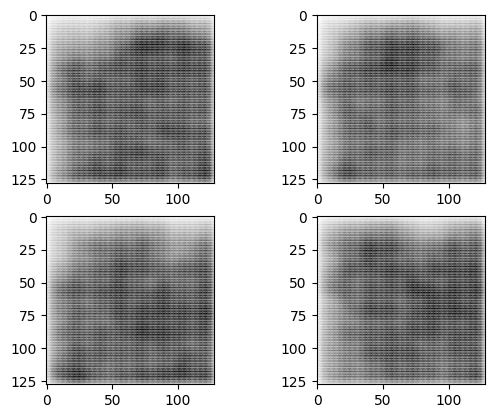


[Q-Net Eval] Epoch 0: NMI=0.0313, ARI=-0.0053, Cluster Acc=0.4071
[Q-Net Eval] Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}

[Q-Net Eval] Confusion Matrix (Epoch 0):
Predicted Categories: ['Cat 0', 'Cat 1', 'Cat 2', 'Cat 3']
Real Subtypes: ['Metastatic', 'Primary Tumor', 'Recurrent Tumor', 'Solid Tissue Normal']
[[  2 390   0   0]
 [  3 718   0   5]
 [  0  45   0   0]
 [  0 677   0  49]]
30/30 ━━━━━━━━━━━━━━━━━━━━ 158s 3s/step - d_loss: -23.7762 - g_loss: 11.2242 - q_loss: 2.4780 - q_sup: 3.7247
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


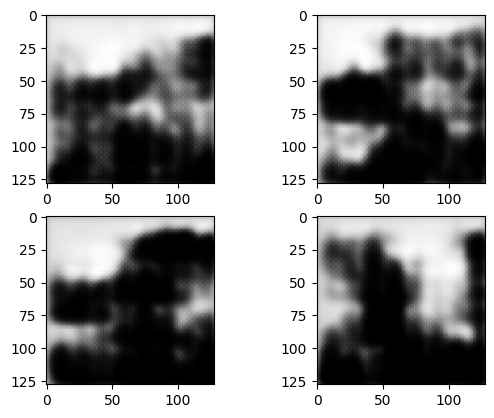


[Q-Net Eval] Epoch 1: NMI=0.0047, ARI=-0.0047, Cluster Acc=0.3886
[Q-Net Eval] Mapping: {np.int64(3): np.int64(0), np.int64(0): np.int64(1), np.int64(2): np.int64(2), np.int64(1): np.int64(3)}
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - d_loss: -75.5809 - g_loss: 18.0599 - q_loss: 3.4485 - q_sup: 6.6316
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


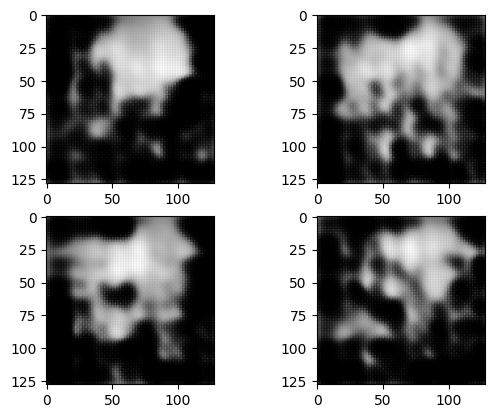


[Q-Net Eval] Epoch 2: NMI=0.0000, ARI=0.0000, Cluster Acc=0.3843
[Q-Net Eval] Mapping: {np.int64(1): np.int64(0), np.int64(0): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - d_loss: -63.9921 - g_loss: 46.0847 - q_loss: 4.7481 - q_sup: 6.6499
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


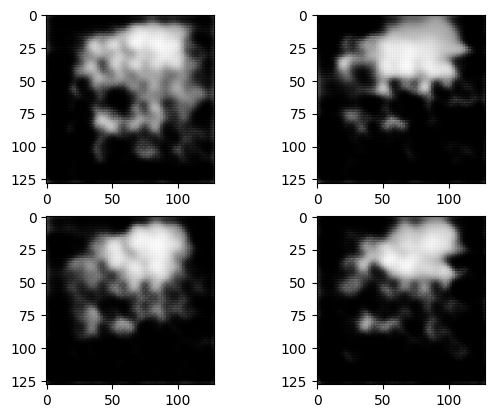


[Q-Net Eval] Epoch 3: NMI=0.0000, ARI=0.0000, Cluster Acc=0.3843
[Q-Net Eval] Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - d_loss: -47.7792 - g_loss: 42.6672 - q_loss: 4.8762 - q_sup: 6.3367
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


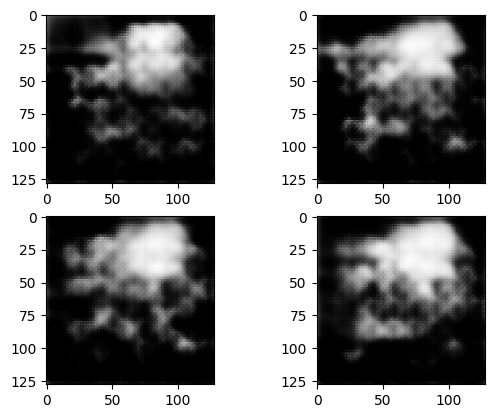


[Q-Net Eval] Epoch 4: NMI=0.0000, ARI=0.0000, Cluster Acc=0.3843
[Q-Net Eval] Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - d_loss: -43.8172 - g_loss: 43.5862 - q_loss: 4.8502 - q_sup: 5.9771
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


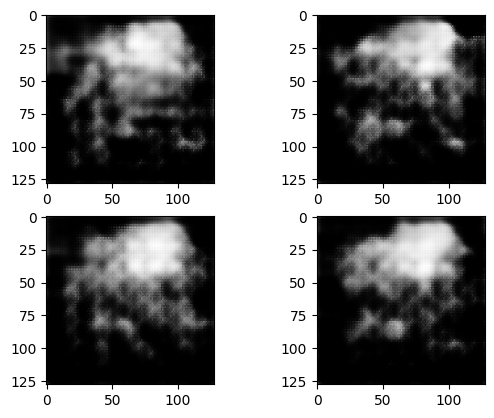


[Q-Net Eval] Epoch 5: NMI=0.0000, ARI=0.0000, Cluster Acc=0.3843
[Q-Net Eval] Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - d_loss: -43.2072 - g_loss: 55.8127 - q_loss: 4.7727 - q_sup: 5.7934
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


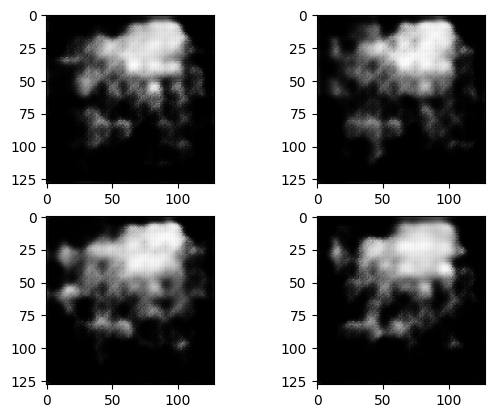


[Q-Net Eval] Epoch 6: NMI=0.0000, ARI=0.0000, Cluster Acc=0.3843
[Q-Net Eval] Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - d_loss: -42.3346 - g_loss: 81.4213 - q_loss: 4.6470 - q_sup: 5.5234
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


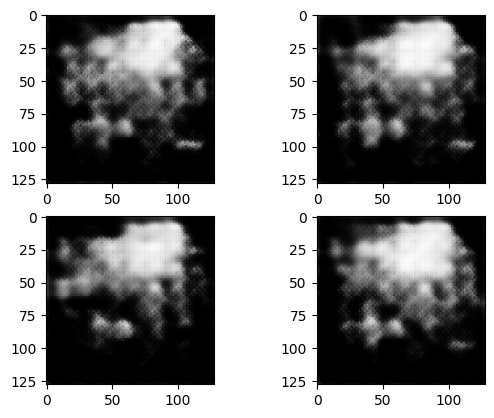


[Q-Net Eval] Epoch 7: NMI=0.0000, ARI=0.0000, Cluster Acc=0.3843
[Q-Net Eval] Mapping: {np.int64(1): np.int64(0), np.int64(3): np.int64(1), np.int64(0): np.int64(2), np.int64(2): np.int64(3)}
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - d_loss: -42.0451 - g_loss: 114.9406 - q_loss: 4.5793 - q_sup: 5.1711
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


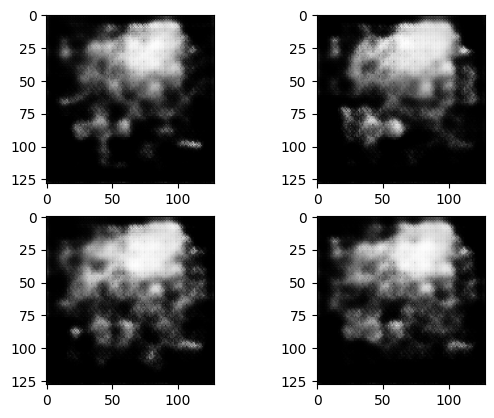


[Q-Net Eval] Epoch 8: NMI=0.0000, ARI=0.0000, Cluster Acc=0.3843
[Q-Net Eval] Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - d_loss: -40.9929 - g_loss: 144.8251 - q_loss: 4.5475 - q_sup: 5.0187
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


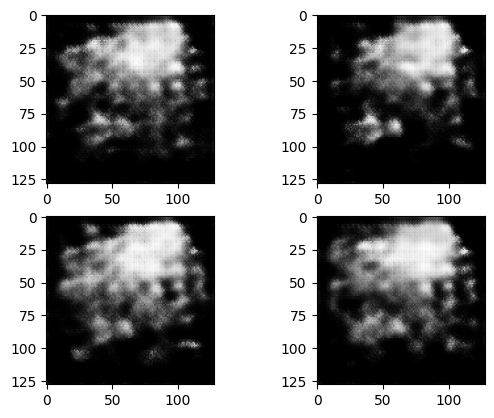


[Q-Net Eval] Epoch 9: NMI=0.0000, ARI=0.0000, Cluster Acc=0.3843
[Q-Net Eval] Mapping: {np.int64(1): np.int64(0), np.int64(3): np.int64(1), np.int64(0): np.int64(2), np.int64(2): np.int64(3)}
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - d_loss: -39.9035 - g_loss: 174.6597 - q_loss: 4.5045 - q_sup: 4.8950
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


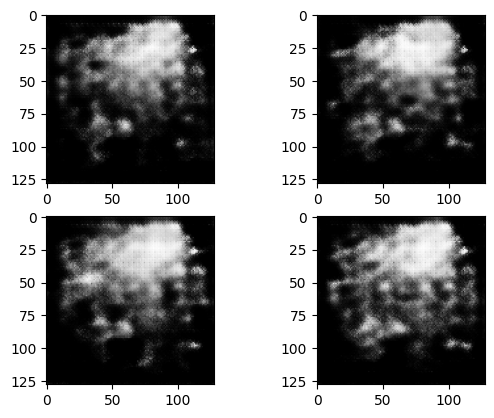


[Q-Net Eval] Epoch 10: NMI=0.0000, ARI=0.0000, Cluster Acc=0.3843
[Q-Net Eval] Mapping: {np.int64(1): np.int64(0), np.int64(0): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}

[Q-Net Eval] Confusion Matrix (Epoch 10):
Predicted Categories: ['Cat 0', 'Cat 1', 'Cat 2', 'Cat 3']
Real Subtypes: ['Metastatic', 'Primary Tumor', 'Recurrent Tumor', 'Solid Tissue Normal']
[[392   0   0   0]
 [726   0   0   0]
 [ 45   0   0   0]
 [726   0   0   0]]
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - d_loss: -38.6767 - g_loss: 191.4830 - q_loss: 4.4524 - q_sup: 4.6846
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


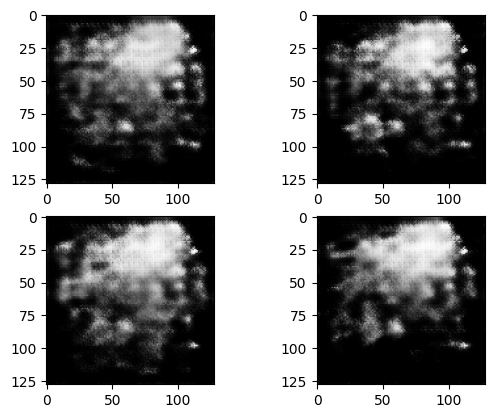


[Q-Net Eval] Epoch 11: NMI=0.0000, ARI=0.0000, Cluster Acc=0.3843
[Q-Net Eval] Mapping: {np.int64(1): np.int64(0), np.int64(3): np.int64(1), np.int64(0): np.int64(2), np.int64(2): np.int64(3)}
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - d_loss: -37.5519 - g_loss: 194.1117 - q_loss: 4.3720 - q_sup: 4.5347
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


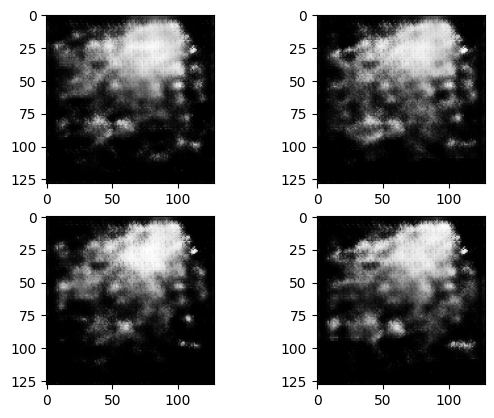


[Q-Net Eval] Epoch 12: NMI=0.0000, ARI=0.0000, Cluster Acc=0.3843
[Q-Net Eval] Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - d_loss: -35.9173 - g_loss: 203.2237 - q_loss: 4.2738 - q_sup: 4.3662
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


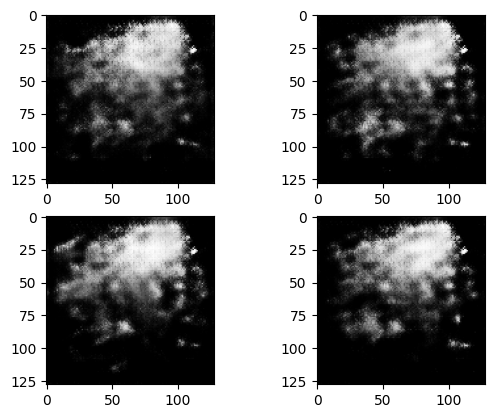


[Q-Net Eval] Epoch 13: NMI=0.0009, ARI=-0.0004, Cluster Acc=0.3849
[Q-Net Eval] Mapping: {np.int64(2): np.int64(0), np.int64(1): np.int64(1), np.int64(0): np.int64(2), np.int64(3): np.int64(3)}
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - d_loss: -34.7509 - g_loss: 189.4757 - q_loss: 4.1764 - q_sup: 4.2117
Epoch 15/500
23/30 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - d_loss: -33.5150 - g_loss: 191.5758 - q_loss: 4.1377 - q_sup: 4.1740 

In [ ]:
cond_infogan.fit(dataset, epochs=500 , callbacks=[callback, q_evaluator, LossLogger()])
# cond_gan.fit(dataset, epochs=20)